<a href="https://colab.research.google.com/github/nickkraus52/MachineLearning/blob/main/HW2/data_prep_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load and Inspect Pandas Dataframe:

In [73]:
import numpy as np
import pandas as pd
df = pd.read_csv('cybersecurity_intrusion_data.csv')

print("First 5 Rows: ")
display(df.head())

print("\nColumn Information: ")
display(df.info())

print("\nData Frame Simple Distribution: ")
display(df.describe())

print(f"\nTotal Elements : {df.size}")

print("\nProtocol Types: ")
display(df["protocol_type"].value_counts())

print("\nBrowser Types: ")
display(df["browser_type"].value_counts())

First 5 Rows: 


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0



Column Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


None


Data Frame Simple Distribution: 


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000



Total Elements : 104907

Protocol Types: 


,count
protocol_type,
TCP,6624
UDP,2406
ICMP,507



Browser Types: 


,count
browser_type,
Chrome,5137
Firefox,1944
Edge,1469
Unknown,502
Safari,485


## Drop any non-informative identifiers:

In [74]:
print("The session_id column contains a unique ID for network traffic.")
print("This doesn't have any correlation to attack detection")

print("\nNew Column Information:")
df.drop(columns="session_id", axis=1, inplace=True)
df.info()

The session_id column contains a unique ID for network traffic.
This doesn't have any correlation to attack detection

New Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   protocol_type        9537 non-null   object 
 2   login_attempts       9537 non-null   int64  
 3   session_duration     9537 non-null   float64
 4   encryption_used      7571 non-null   object 
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   int64  
 7   browser_type         9537 non-null   object 
 8   unusual_time_access  9537 non-null   int64  
 9   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 745.2+ KB


## Quantifying and Imputing Missing Values:

In [75]:
print("Missing Values: ")
df.isnull().sum()

Missing Values: 


,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [76]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="constant", fill_value="None")
df["encryption_used"] = imputer.fit_transform(df[["encryption_used"]]).ravel()

print("Missing Values: ")
df.isnull().sum()

Missing Values: 


,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


## Isolating Feature Types and Building Pre-processing Pipeline

In [96]:
X = df.drop(columns="attack_detected")
y = df["attack_detected"]

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=[np.object_]).columns.tolist()

print(f"Numerical Features: {numerical_features}")

print(f"\nCategorical Features: {categorical_features}")



Numerical Features: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access']

Categorical Features: ['protocol_type', 'encryption_used', 'browser_type']


In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler())])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)])

full_pipeline = Pipeline(steps=[("preprocessing", preprocessing)])
X_transform = full_pipeline.fit_transform(X)

display(full_pipeline)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardize',
                                                                   StandardScaler())]),
                                                  ['network_packet_size',
                                                   'login_attempts',
                                                   'session_duration',
                                                   'ip_reputation_score',
                                                   'failed_logins',
                                                   'unusual_time_access']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['protocol_type',
                                                   'encryption_used',
                                                   'browser_type'])]))])

## Pearson Correlation Matrix:

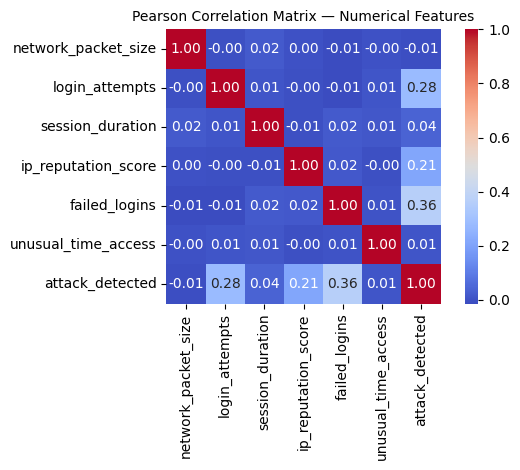

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df[numerical_features + ["attack_detected"]]
corr_matrix = numeric_df.corr(method="pearson")
corr_matrix.round(2)

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Pearson Correlation Matrix — Numerical Features", fontsize=10)
plt.tight_layout()
plt.show()

## Disribution Plot 1 - Attacked Detected By Packet Size

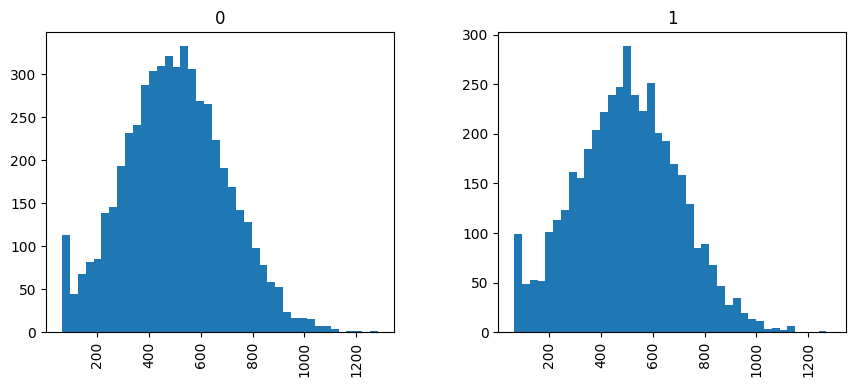

In [109]:
df.hist(column="network_packet_size", by="attack_detected", bins=40,
        figsize=(10, 4), sharex=True)
plt.show()

## Disribution Plot 2 - Attacked Detected By Session Duration

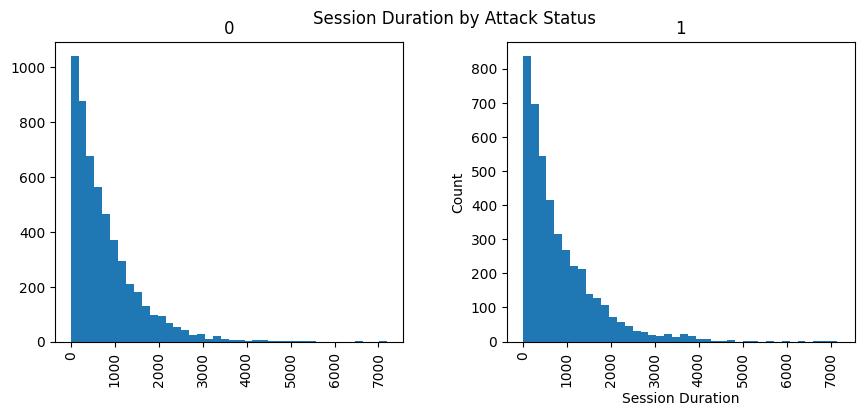

In [117]:
df.hist(column="session_duration", by="attack_detected", bins=40,
        figsize=(10, 4), sharex=True)
plt.suptitle("Session Duration by Attack Status")
plt.xlabel("Session Duration")
plt.ylabel("Count")
plt.show()

## Scatter Plot - Failed Logins by IP Reputation Score

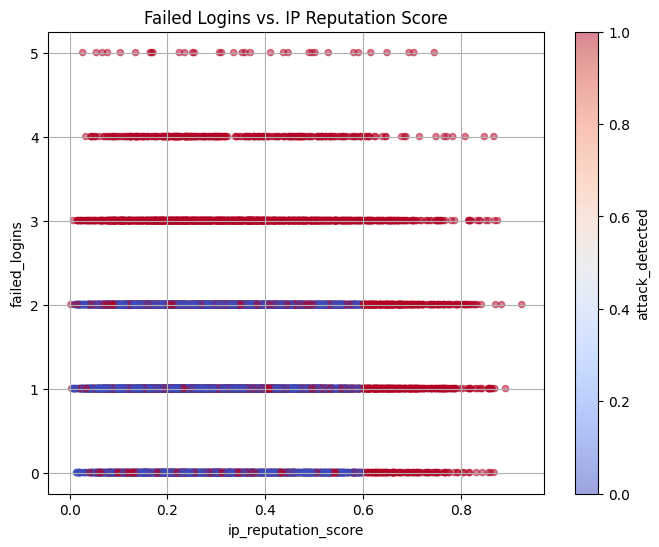

In [112]:
df.plot(kind="scatter", x="ip_reputation_score", y="failed_logins",
        c="attack_detected", cmap="coolwarm", alpha=0.5, grid=True,
        figsize=(8, 6))
plt.title("Failed Logins vs. IP Reputation Score")
plt.show()